High Vol vs Low Vol | Bull vs Bear (Publication Ready)

 Final model loaded: quantum_alpha_final.pth

=== REGIME-SPECIFIC PERFORMANCE TABLE ===
     Regime  CAGR (%)  Sharpe  MaxDD (%)  Long %  Short %  Flat %  Days
0  High Vol     29.44  1.1724     -13.78    16.5     21.8    61.7   764
1   Low Vol     -3.02 -1.9020     -12.24     5.9     17.8    76.3   765
2      Bull      6.73  0.0382     -16.61     9.3     16.4    74.4   855
3      Bear     13.38  0.4322     -18.26    12.3     25.6    62.1   674


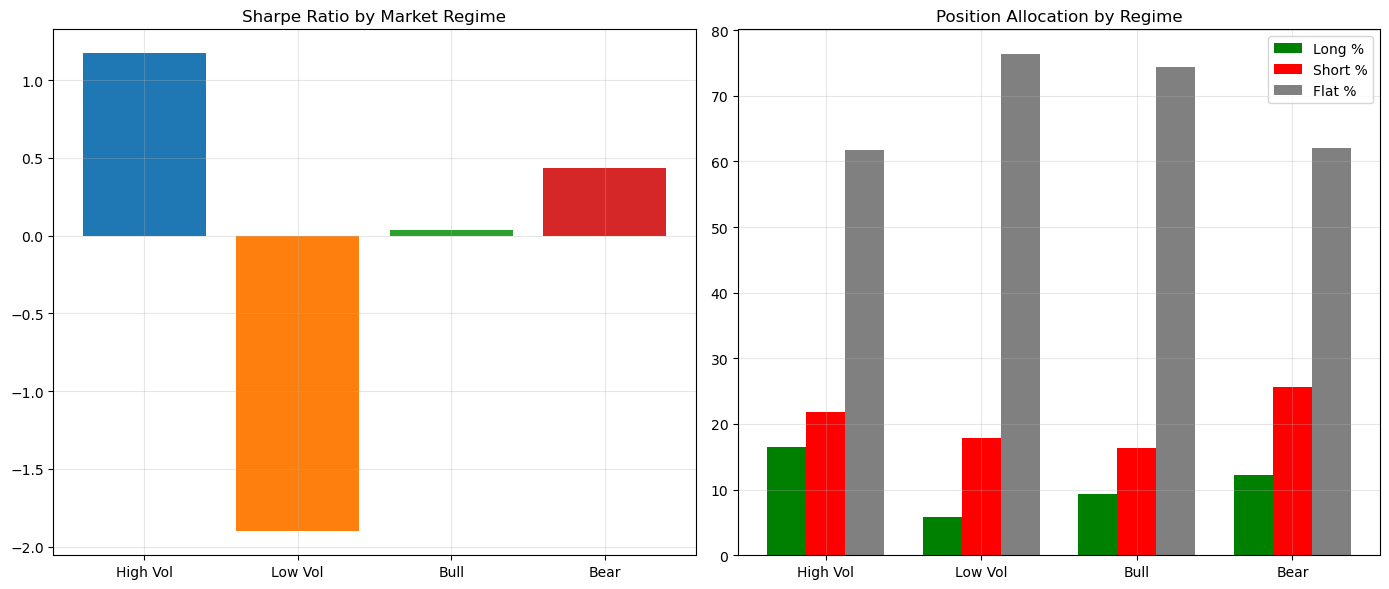

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("High Vol vs Low Vol | Bull vs Bear (Publication Ready)\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. FINAL DQN MODEL
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/quantum_alpha_final.pth", map_location=device))
policy_net.eval()
print(" Final model loaded: quantum_alpha_final.pth")

# =============================================
# 2. ENVIRONMENT
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.max_steps = len(self.data) - 1
        self.reset()
   
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
   
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        return np.append(obs, self.position)
   
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * ret - cost
        self.balance *= (1 + net_ret)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self._get_observation(), net_ret, done, {"net_ret": net_ret, "position": self.position}

# =============================================
# 3. LOAD FULL DATA
# =============================================
full_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
full_data = full_data.join(pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)[["nifty_ret"]])

# =============================================
# 4. DEFINE REGIMES
# =============================================
# High Vol / Low Vol based on median vol_signal_norm
median_vol = full_data["vol_signal_norm"].median()
full_data["Vol_Regime"] = np.where(full_data["vol_signal_norm"] > median_vol, "High Vol", "Low Vol")

# Bull / Bear based on trend_signal_norm
full_data["Market_Regime"] = np.where(full_data["trend_signal_norm"] > 0, "Bull", "Bear")

regimes = {
    "High Vol": full_data[full_data["Vol_Regime"] == "High Vol"],
    "Low Vol":  full_data[full_data["Vol_Regime"] == "Low Vol"],
    "Bull":     full_data[full_data["Market_Regime"] == "Bull"],
    "Bear":     full_data[full_data["Market_Regime"] == "Bear"]
}

# =============================================
# 5. RUN AGENT ON EACH REGIME
# =============================================
def run_on_regime(regime_data, name):
    env = QuantumAlphaEnv(regime_data)
    state = env.reset()
    done = False
    equity = 1.0
    equity_curve = [1.0]
    returns = []
    positions = []
    while not done:
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = policy_net(s).argmax().item()
        next_state, _, done, info = env.step(action)
        equity *= (1 + info["net_ret"])
        equity_curve.append(equity)
        returns.append(info["net_ret"])
        positions.append(info["position"])
        state = next_state
    equity_arr = np.array(equity_curve)
    returns = np.array(returns)
    pos = np.array(positions)
    
    days = len(returns)
    cagr = equity_arr[-1] ** (252 / days) - 1 if days > 0 else 0
    sharpe = (np.mean(returns) - 0.065/252) / (np.std(returns) + 1e-8) * np.sqrt(252) if days > 0 else 0
    max_dd = (equity_arr / np.maximum.accumulate(equity_arr) - 1).min()
    
    return {
        "Regime": name,
        "CAGR (%)": round(cagr*100, 2),
        "Sharpe": round(sharpe, 4),
        "MaxDD (%)": round(max_dd*100, 2),
        "Long %": round((pos == 1).mean()*100, 1),
        "Short %": round((pos == -1).mean()*100, 1),
        "Flat %": round((pos == 0).mean()*100, 1),
        "Days": len(regime_data)
    }

results = []
for name, data in regimes.items():
    results.append(run_on_regime(data, name))

regime_table = pd.DataFrame(results)
print("\n=== REGIME-SPECIFIC PERFORMANCE TABLE ===")
print(regime_table)

# =============================================
# 6. VISUALISATION
# =============================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Sharpe by regime
ax[0].bar(regime_table["Regime"], regime_table["Sharpe"], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
ax[0].set_title("Sharpe Ratio by Market Regime")
ax[0].grid(True, alpha=0.3)

# Position allocation
x = np.arange(len(regime_table))
width = 0.25
ax[1].bar(x - width, regime_table["Long %"], width, label="Long %", color="green")
ax[1].bar(x, regime_table["Short %"], width, label="Short %", color="red")
ax[1].bar(x + width, regime_table["Flat %"], width, label="Flat %", color="gray")
ax[1].set_xticks(x)
ax[1].set_xticklabels(regime_table["Regime"])
ax[1].set_title("Position Allocation by Regime")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()